<a href="https://colab.research.google.com/github/Alireza-hakimi/Explainable-AI-model-implementation/blob/main/model1_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv("fraud_data.csv")

print("=" * 50)
print(f"Dataset Shape     : {df.shape}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")
print("=" * 50)
df.head()

Dataset Shape     : (14446, 15)
Missing Values    : 0
Duplicate Rows    : 63


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


In [ ]:
# Fix corrupted target column
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce')
df = df.dropna(subset=['is_fraud'])
df['is_fraud'] = df['is_fraud'].astype(int)
df = df[df['is_fraud'].isin([0, 1])]

# Extract time features from transaction datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='mixed', dayfirst=True)
df['hour']        = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

# Calculate distance between customer and merchant
df['distance_km'] = np.sqrt(
    (df['lat'] - df['merch_lat'])**2 +
    (df['long'] - df['merch_long'])**2
) * 111

# Encode categorical features
le = LabelEncoder()
for col in ['category', 'city', 'state', 'job']:
    df[col] = le.fit_transform(df[col].astype(str))

print("Cleaned Class Distribution:")
print(df['is_fraud'].value_counts())
print(f"\nFraud Rate : {df['is_fraud'].mean() * 100:.2f}%")

Cleaned Class Distribution:
is_fraud
0    12600
1     1844
Name: count, dtype: int64

Fraud Rate : 12.77%


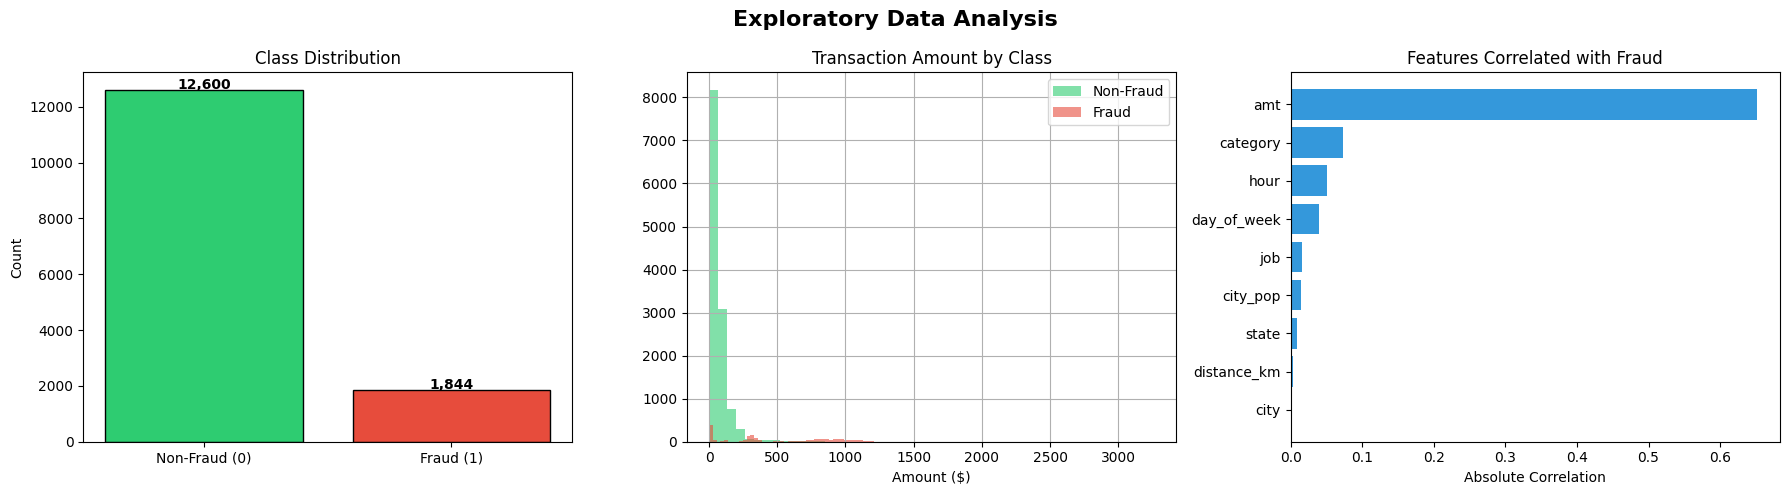

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight="bold")

# Class distribution
axes[0].bar(["Non-Fraud (0)", "Fraud (1)"],
            df["is_fraud"].value_counts().values,
            color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(df["is_fraud"].value_counts().values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

# Amount distribution by class
df[df["is_fraud"] == 0]["amt"].hist(ax=axes[1], bins=50, alpha=0.6,
                                    color="#2ecc71", label="Non-Fraud")
df[df["is_fraud"] == 1]["amt"].hist(ax=axes[1], bins=50, alpha=0.6,
                                    color="#e74c3c", label="Fraud")
axes[1].set_title("Transaction Amount by Class")
axes[1].set_xlabel("Amount ($)")
axes[1].legend()

# Top correlated features
feature_cols = ['category', 'amt', 'city', 'state', 'city_pop',
                'job', 'distance_km', 'hour', 'day_of_week']
corr = df[feature_cols + ['is_fraud']].corr()["is_fraud"].drop("is_fraud").abs().sort_values(ascending=False)
axes[2].barh(corr.index[::-1], corr.values[::-1], color="#3498db")
axes[2].set_title("Features Correlated with Fraud")
axes[2].set_xlabel("Absolute Correlation")

plt.tight_layout()
plt.show()

In [ ]:
feature_columns = ['category', 'amt', 'city', 'state', 'city_pop',
                   'job', 'distance_km', 'hour', 'day_of_week']
X = df[feature_columns]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")
print(f"\nTrain fraud rate : {y_train.mean() * 100:.2f}%")
print(f"Test fraud rate  : {y_test.mean() * 100:.2f}%")

Train size : 11,555
Test size  : 2,889

Train fraud rate : 12.77%
Test fraud rate  : 12.77%


In [ ]:
imbalance_ratio = sum(y_train == 0) / sum(y_train == 1)
print(f"Imbalance ratio : {imbalance_ratio:.2f}")

model = xgb.XGBClassifier(
    scale_pos_weight      = imbalance_ratio,
    n_estimators          = 300,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = "auc",
    early_stopping_rounds = 20,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f"\nBest iteration : {model.best_iteration}")
print("Model training complete!")

Imbalance ratio : 6.83
[0]	validation_0-auc:0.88067
[50]	validation_0-auc:0.98945
[100]	validation_0-auc:0.99234
[150]	validation_0-auc:0.99360
[169]	validation_0-auc:0.99346

Best iteration : 149
Model training complete!


In [ ]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
f1  = f1_score(y_test, y_pred)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"AUC-ROC Score : {auc:.4f}")
print(f"F1 Score      : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))

TEST SET RESULTS
AUC-ROC Score : 0.9936
F1 Score      : 0.9160

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.98      0.99      2520
       Fraud       0.89      0.95      0.92       369

    accuracy                           0.98      2889
   macro avg       0.94      0.96      0.95      2889
weighted avg       0.98      0.98      0.98      2889



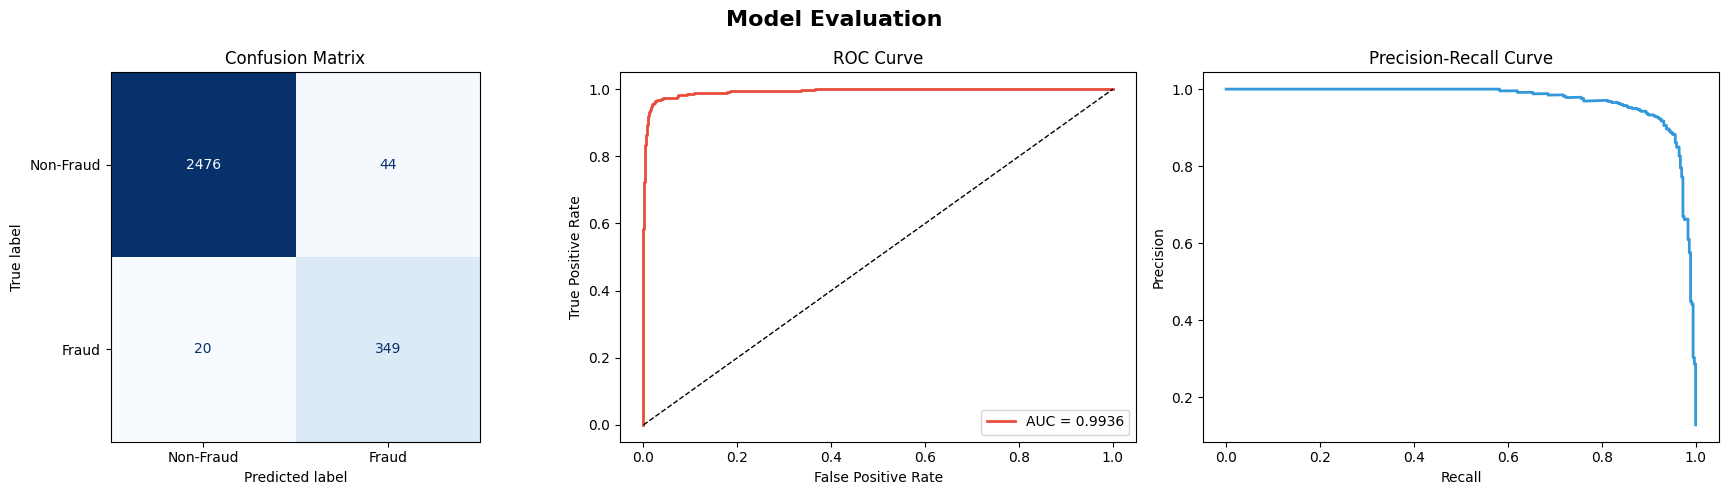

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation", fontsize=16, fontweight="bold")

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Non-Fraud", "Fraud"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(recall, precision, color="#3498db", lw=2)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [ ]:
model.save_model("xgboost_fraud_model1.json")
print("Model saved as: xgboost_fraud_model1.json")
print("Ready for XAI analysis!")

Model saved as: xgboost_fraud_model1.json
Ready for XAI analysis!


In [ ]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test, check_additivity=False)

np.save("shap_values_model1.npy", shap_values)
print(f"SHAP values shape : {shap_values.shape}")
print(f"Test set shape    : {X_test.shape}")
print("SHAP analysis complete!")

SHAP values shape : (2889, 9)
Test set shape    : (2889, 9)
SHAP analysis complete!


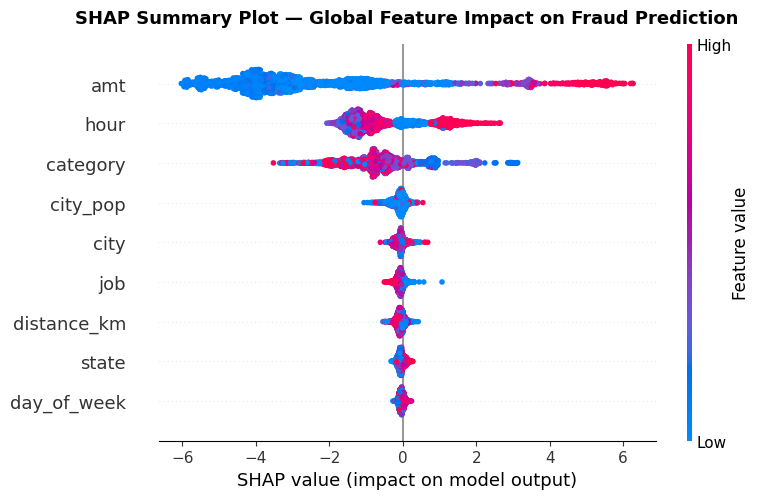

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary Plot — Global Feature Impact on Fraud Prediction", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

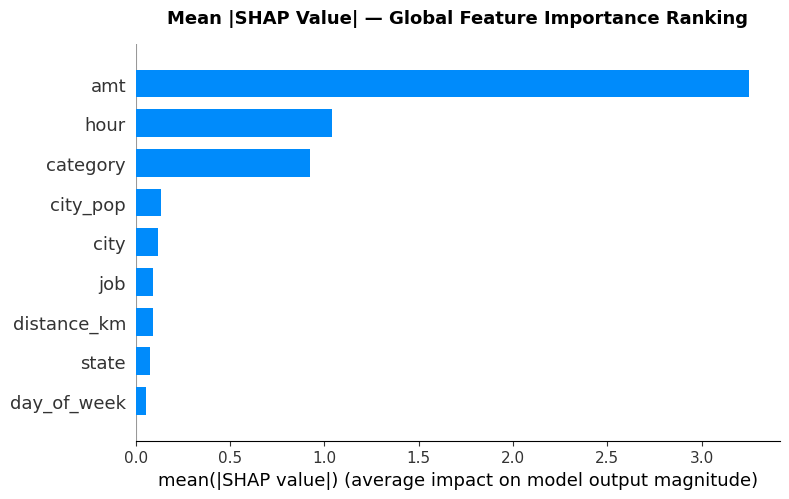

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.title("Mean |SHAP Value| — Global Feature Importance Ranking", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

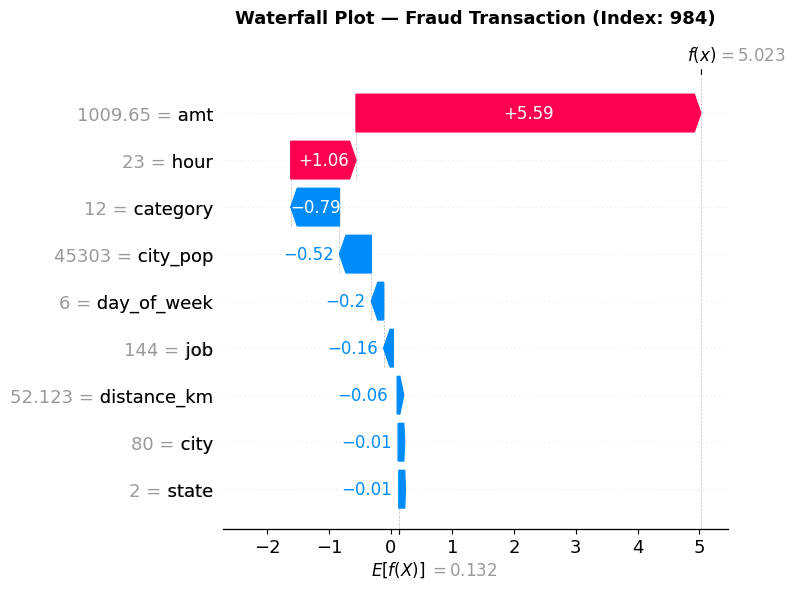

Transaction Index : 984
True Label        : FRAUD
Fraud Probability : 0.9935


In [ ]:
fraud_indices = y_test[y_test == 1].index
sample_idx    = fraud_indices[0]
position      = X_test.index.get_loc(sample_idx)

shap.plots.waterfall(shap.Explanation(
    values        = shap_values[position],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[position],
    feature_names = X_test.columns.tolist()
), max_display=15, show=False)
plt.title(f"Waterfall Plot — Fraud Transaction (Index: {sample_idx})", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print(f"Transaction Index : {sample_idx}")
print(f"True Label        : FRAUD")
print(f"Fraud Probability : {model.predict_proba(X_test.iloc[[position]])[0][1]:.4f}")

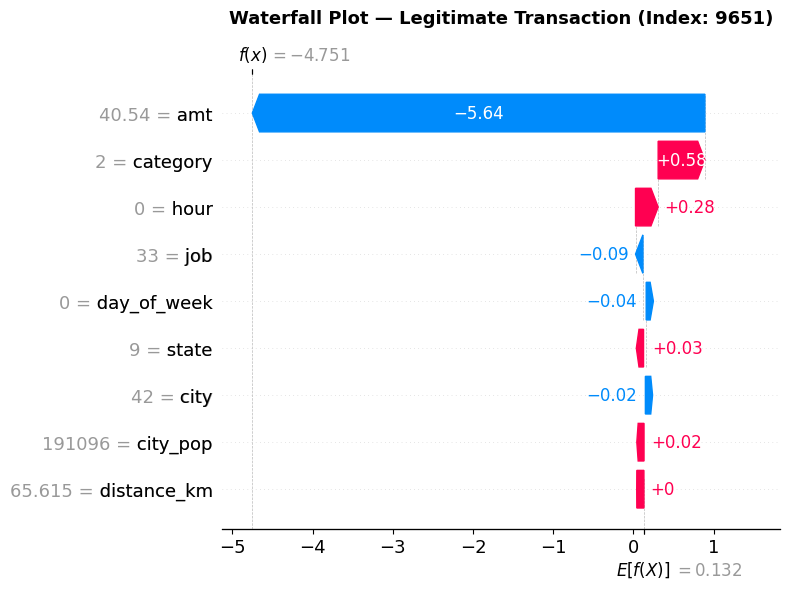

Transaction Index : 9651
True Label        : NON-FRAUD
Fraud Probability : 0.0086


In [ ]:
legit_indices = y_test[y_test == 0].index
sample_idx2   = legit_indices[0]
position2     = X_test.index.get_loc(sample_idx2)

shap.plots.waterfall(shap.Explanation(
    values        = shap_values[position2],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[position2],
    feature_names = X_test.columns.tolist()
), max_display=15, show=False)
plt.title(f"Waterfall Plot — Legitimate Transaction (Index: {sample_idx2})", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print(f"Transaction Index : {sample_idx2}")
print(f"True Label        : NON-FRAUD")
print(f"Fraud Probability : {model.predict_proba(X_test.iloc[[position2]])[0][1]:.4f}")

In [ ]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[position],
    X_test.iloc[position],
    feature_names=X_test.columns.tolist()
)
